In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

In [4]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [5]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [7]:
data = pd.read_csv("amazonreviews.tsv", delimiter='\t')

print(data.head())

  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...


In [8]:
print("Dataset Shape:")
print(data.shape)

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nClass Distribution:")
print(data['label'].value_counts())

Dataset Shape:
(10000, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB
None

Missing Values:
label     0
review    0
dtype: int64

Class Distribution:
label
neg    5097
pos    4903
Name: count, dtype: int64


The dataset contains Amazon customer reviews labeled as positive or negative sentiments.

Positive reviews are labeled as:
pos

Negative reviews are labeled as:
neg

The dataset is used to train a sentiment analysis model.

In [9]:
ps = PorterStemmer()

corpus = []

for i in range(len(data)):

    review = re.sub('[^a-zA-Z]', ' ', data['review'][i])

    review = review.lower()

    review = review.split()

    review = [ps.stem(word) for word in review
              if not word in stopwords.words('english')]

    review = ' '.join(review)

    corpus.append(review)

print(corpus[:5])

['stune even non gamer sound track beauti paint seneri mind well would recomend even peopl hate vid game music play game chrono cross game ever play best music back away crude keyboard take fresher step grate guitar soul orchestra would impress anyon care listen', 'best soundtrack ever anyth read lot review say best game soundtrack figur write review disagre bit opinino yasunori mitsuda ultim masterpiec music timeless listen year beauti simpli refus fade price tag pretti stagger must say go buy cd much money one feel would worth everi penni', 'amaz soundtrack favorit music time hand intens sad prison fate mean play game hope distant promis girl stole star import inspir person throughout teen year higher energi track like chrono cross time scar time dreamwatch chronomantiqu indefin remenisc chrono trigger absolut superb well soundtrack amaz music probabl best compos work heard xenogear soundtrack say sure even never play game would worth twice price buy wish could give star', 'excel sou

In [10]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(corpus).toarray()

y = data['label']

In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(y)

[1 1 1 ... 0 0 1]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (8000, 5000)
Testing Shape: (2000, 5000)


In [13]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [14]:
y_pred = model.predict(X_test)


In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.825

Confusion Matrix:
[[878 159]
 [191 772]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1037
           1       0.83      0.80      0.82       963

    accuracy                           0.82      2000
   macro avg       0.83      0.82      0.82      2000
weighted avg       0.83      0.82      0.82      2000



Accuracy: 0.825

Confusion Matrix:
[[878 159]
 [191 772]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1037
           1       0.83      0.80      0.82       963

    accuracy                           0.82      2000
   macro avg       0.83      0.82      0.82      2000
weighted avg       0.83      0.82      0.82      2000



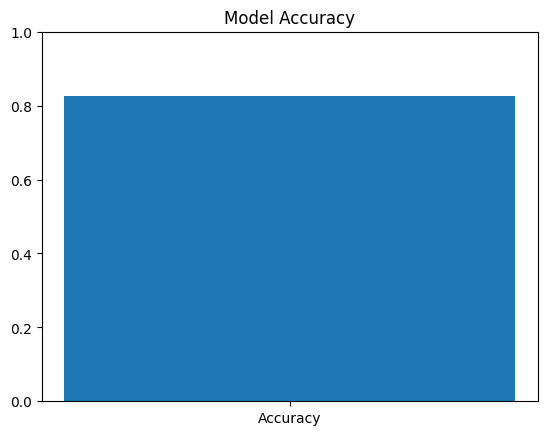

In [17]:
labels = ['Accuracy']

scores = [accuracy]

plt.bar(labels, scores)

plt.title('Model Accuracy')

plt.ylim(0,1)

plt.show()

In [18]:
sample_review = "This product is excellent and very useful"

sample_review = re.sub('[^a-zA-Z]', ' ', sample_review)

sample_review = sample_review.lower()

sample_review = sample_review.split()

sample_review = [ps.stem(word) for word in sample_review
                 if not word in stopwords.words('english')]

sample_review = ' '.join(sample_review)

sample_review = tfidf.transform([sample_review]).toarray()

prediction = model.predict(sample_review)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review


Conclusion

The sentiment analysis model successfully classified Amazon customer reviews into positive and negative sentiments.

Text preprocessing and TF-IDF vectorization improved text representation.

The Naive Bayes classifier achieved good accuracy in predicting customer sentiment automatically.

This system can help e-commerce companies monitor customer satisfaction and product quality in real time.